In [2]:
import numpy as np
import librosa
import audioflux as af
import soundfile as sf
import matplotlib.pyplot as plt
import sklearn
import scipy
import writing
import analysis

c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


None
..\..\corpus\metro_sample_1\input.wav
True


In [21]:
input_file = "..\..\corpus\\metro_sample_1\input.wav"
output_dir = "..\..\corpus\\metro_sample_1"

sr=48000
grain_duration = 0.1 # in s

y, sr = af.read(input_file, samplate=sr) # sr is 48kHz

grain_size = int(grain_duration * sr)
n_grains_in_source = int(len(y) // grain_size)
grains = [i*grain_size for i in range(n_grains_in_source)]

# since BFT is based on the FFT, the number of bins needs to be half that of a power of 2
bft_obj = af.BFT(num=2049, samplate=sr, radix2_exp=12, slide_length=grain_size,
               data_type=af.type.SpectralDataType.MAG,
               scale_type=af.type.SpectralFilterBankScaleType.LINEAR)
spec_arr = bft_obj.bft(y)
spec_arr = np.abs(spec_arr)
spectral_obj = af.Spectral(num=bft_obj.num,
                           fre_band_arr=bft_obj.get_fre_band_arr())
n_time = spec_arr.shape[-1]  
spectral_obj.set_time_length(n_time)
rms_arr = spectral_obj.rms(spec_arr)
flatness_arr = spectral_obj.flatness(spec_arr)



In [35]:
flatness_matrix = [[0.8,0.2],[0.6,0.4]]
rms_matrix = flatness_matrix
# s1 is low rms or low flatness, 2 is high
# high and low are based on low half high half, and there we set the clusters. 
rms_l, rms_h = np.min(rms_arr), np.max(rms_arr)
rms_centroids = [rms_h-rms_l*0.25, rms_h-rms_l*0.75]
flatness_l, flatness_h = np.min(flatness_arr), np.max(flatness_arr)
f_centroids = [flatness_h-flatness_l*0.25, flatness_h-flatness_l*0.75]

clusters = []
for i, row in enumerate(flatness_matrix):
    for j, _ in enumerate(row):
        clusters.append([f_centroids[i], rms_centroids[j]])

n_clusters = len(clusters)

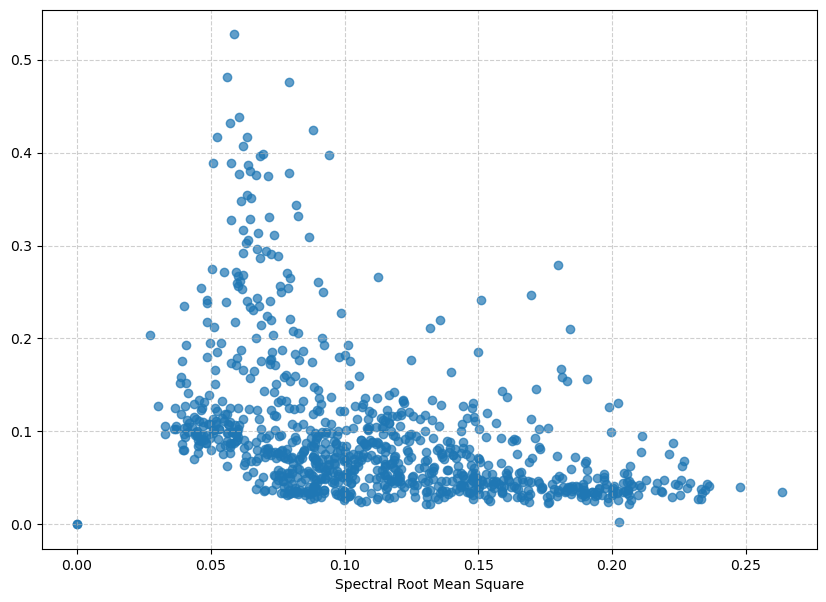

In [23]:

n_clusters=len(clusters)
x = np.array([[i, j] for i, j in zip(rms_arr, flatness_arr)])
kmeans = sklearn.cluster.KMeans(n_clusters=n_clusters, init=clusters, n_init=1, random_state=0).fit(x)
plt.figure(figsize=(10, 7))
plt.scatter(flatness_arr, rms_arr, alpha=0.7)
# plt.ylabel()
plt.xlabel("Spectral Root Mean Square")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

dict_clusters = {}
for idx, lab in enumerate(kmeans.labels_):
    dict_clusters[lab] = dict_clusters.get(lab, [])
    dict_clusters[lab].append(idx)

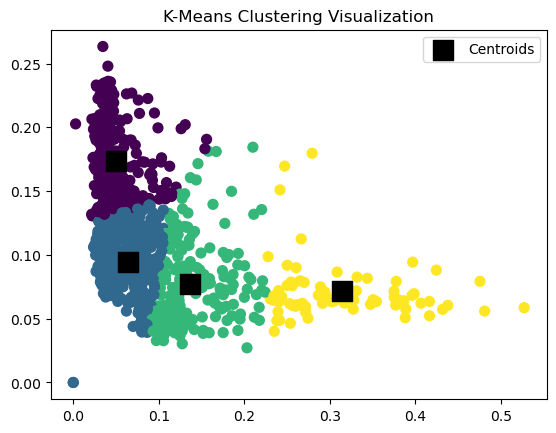

In [29]:
plt.scatter(x[:, 0], x[:, 1], c=kmeans.labels_, cmap='viridis', s=50)

# Plotting the centroids as large red stars
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker=',', label='Centroids')

plt.title("K-Means Clustering Visualization")
plt.legend()
plt.show()

### Define the matrix
See logs in notebook_logs.md


In [ ]:
# TPM
tpm = [
    [0.6, 0.15, 0.15, 0.1],
    [0.1, 0.4, 0.4, 0.1],
    [0.1, 0.4, 0.4, 0.1],
    [0.3, 0, 0, 0.7]
    ]


In [ ]:
window = np.hanning
output_buffer = np.array([]) 
curr_state = 2
n_iterations = 100
seed = 100
s = np.random.seed(seed)

for i in range(n_iterations):

    next_label = np.random.choice(range(n_clusters), p=tpm[curr_state])
    grain_idx = np.random.choice(dict_clusters[next_label]) # uniform sampling from a cluster
    grain_y_idx = grains[grain_idx]
    grain = y[grain_y_idx:grain_y_idx+grain_size]
    grain = grain * np.hanning(grain_size)
    output_buffer = np.concatenate([output_buffer, grain])
    curr_label = next_label
# output_buffer / np.max(np.abs(output_buffer))


0.05


In [ ]:
try:
    window_name = window.__name__
except AttributeError as e:
    window_name = "None"
parametre_dict = {
    "random_seed" : seed,
    "sample_rate" : sr,
    "input_file" : input_file, 
    "n_clusters" : n_clusters,
    # "densities" : densities,
    # "grain_sizes" : sizes,
    "n_iterations" : n_iterations,
    # "stereo_shifts" : stereo_shifting,
    "delta_t" : delta_t,
    # "max_grains" : max_grains,
    # "num_chans" : num_chans,
    # "init_states_densities_sizes" : [int(i) for i in init_poisson_states],
    # "init_states_grain_cluster" : [int(i) for i in init_cluster_states],
    # "git_hash" : TODO: add git hash,
    "project" : "markov_gs",
    # "poisson_change_rates" : int(density_change_rate),
    "window" : window_name,
    "gs_method": "base_concatenative_synthesis_1"
}

writing.save_output_data(output_buffer.T, sr, parametre_dict, output_dir)

<class 'int'>
<class 'int'>
<class 'str'>
<class 'int'>
<class 'list'>
<class 'list'>
<class 'int'>
<class 'list'>
<class 'float'>
<class 'int'>
<class 'int'>
<class 'list'>
<class 'list'>
<class 'str'>
<class 'int'>
<class 'str'>
